# InternVL3 Document-Aware Extraction Demo

## Simplified YAML-First Architecture with Document-Specific Field Filtering

This notebook demonstrates the simplified `internvl3_document_aware.py` system with **YAML-first document detection** and **document-aware field filtering** that intelligently selects relevant fields based on document type.

### 📋 Complete Semantically Grouped Field Schema (49 fields)
The system supports extraction of these fields from `evaluation_data/ground_truth.csv`:

**Document Identification:**
`DOCUMENT_TYPE`, `INVOICE_NUMBER`, `RECEIPT_NUMBER`

**Business Details:**
`SUPPLIER_NAME`, `BUSINESS_ABN`, `BUSINESS_ADDRESS`, `BUSINESS_PHONE`, `SUPPLIER_WEBSITE`, `SUPPLIER_EMAIL`

**Customer Information:**
`PAYER_NAME`, `PAYER_ABN`, `PAYER_ADDRESS`, `PAYER_PHONE`, `PAYER_EMAIL`

**Temporal Data:**
`INVOICE_DATE`, `DUE_DATE`, `TRANSACTION_DATE`, `STATEMENT_DATE_RANGE`, `CREDIT_CARD_DUE_DATE`

**Line Items:**
`LINE_ITEM_DESCRIPTIONS`, `LINE_ITEM_QUANTITIES`, `LINE_ITEM_PRICES`, `LINE_ITEM_TOTAL_PRICES`, `LINE_ITEM_GST_AMOUNTS`, `LINE_ITEM_DISCOUNT_AMOUNTS`

**Financial Totals:**
`SUBTOTAL_AMOUNT`, `TOTAL_DISCOUNT_AMOUNT`, `GST_AMOUNT`, `IS_GST_INCLUDED`, `TOTAL_AMOUNT`, `TOTAL_AMOUNT_PAID`, `BALANCE_OF_PAYMENT`, `TOTAL_AMOUNT_PAYABLE`

**Payment & Location:**
`PAYMENT_METHOD`, `STORE_LOCATION`

**Banking Information:**
`BANK_NAME`, `BANK_BSB_NUMBER`, `BANK_ACCOUNT_NUMBER`, `BANK_ACCOUNT_HOLDER`, `ACCOUNT_OPENING_BALANCE`, `ACCOUNT_CLOSING_BALANCE`

**Transactions:**
`TOTAL_CREDITS`, `TOTAL_DEBITS`, `NET_TRANSACTION_AMOUNT`, `TRANSACTION_DATES`, `TRANSACTION_AMOUNTS_PAID`, `TRANSACTION_AMOUNTS_RECEIVED`, `TRANSACTION_BALANCES`

### 🎯 Document-Aware Field Filtering

**Key Innovation:** The system uses **simplified YAML-first document detection** and intelligently filters to document-specific subsets:

- **📄 Invoice Documents**: 29 relevant fields (41% reduction)
- **🧾 Receipt Documents**: 20 relevant fields (59% reduction)  
- **🏦 Bank Statements**: 16 relevant fields (67% reduction)

This targeted approach delivers:
- ⚡ **Faster processing** with fewer fields to extract
- 🎯 **Higher accuracy** with document-specific prompts
- 💡 **Better resource utilization** focusing on relevant data
- 📈 **Improved performance** through YAML-first prompt configuration
- 🧹 **Consistent architecture** identical to Llama (same YAML-first approach)
- 💾 **Memory efficient** InternVL3-8B optimized for V100 GPUs

---

In [1]:
# CRITICAL: V100 Memory Configuration (Based on docs/V100_MEMORY_STRATEGIES.md)
# This cell configures V100-specific optimizations that are ESSENTIAL for InternVL3-8B


import gc
import os

import torch

# CRITICAL: Enable MPS fallback for unsupported operations on Mac M1/M2

# CRITICAL: Set V100-optimized CUDA memory allocation (from working system)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:64'
print("🔧 CUDA memory allocation configured: max_split_size_mb:64 (V100 optimized)")

# Import V100-optimized memory management functions from common module
from common.gpu_optimization import clear_gpu_cache, emergency_cleanup, cleanup_model_handler

print("💡 V100 memory management functions imported from common.gpu_optimization")
print("💡 Functions available:")
print("   - cleanup_model_handler(): Clean up model handlers before reinitializing")
print("   - clear_gpu_cache(): Clear GPU memory cache")
print("   - emergency_cleanup(): Aggressive cleanup for OOM recovery")

🔧 CUDA memory allocation configured: max_split_size_mb:64 (V100 optimized)
💡 V100 memory management functions imported from common.gpu_optimization
💡 Functions available:
   - cleanup_model_handler(): Clean up model handlers before reinitializing
   - clear_gpu_cache(): Clear GPU memory cache
   - emergency_cleanup(): Aggressive cleanup for OOM recovery


In [2]:
# Import required libraries
import os
import sys
import time
from pathlib import Path

from IPython.display import Image, display

# Set project root (notebook is now in project root)
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

# Import InternVL3 document-aware system using handler pattern (same as Llama)
from common.evaluation_metrics import load_ground_truth
from internvl3_document_aware_handler import DocumentAwareInternVL3Handler

print("📚 Libraries imported successfully")
print(f"🗂️ Project root: {project_root}")
print(f"📍 Current directory: {Path.cwd()}")

📚 Libraries imported successfully
🗂️ Project root: /home/jovyan/nfs_share/tod/LMM_POC
📍 Current directory: /home/jovyan/nfs_share/tod/LMM_POC


## Configuration

Set up the InternVL3 document-aware processor with your model path:

In [3]:
# Configuration - UPDATE WITH YOUR MODEL PATH
# MODEL_PATH = "/efs/shared/PTM/InternVL3-8B"
MODEL_PATH = "/home/jovyan/nfs_share/models/InternVL3-8B"

# TEST_IMAGE = "evaluation_data/image_042.png"  # INVOICE example
# TEST_IMAGE = "evaluation_data/image_005.png"  # RECEIPT example  
TEST_IMAGE = "evaluation_data/image_001.png"  # RECEIPT example
# TEST_IMAGE = "evaluation_data/image_006.png"  # Bank statement example

GROUND_TRUTH_PATH = "evaluation_data/ground_truth.csv"

# Clean up any existing models before initializing new handler
# Uses the common module function for consistent cleanup across notebooks
cleanup_model_handler('handler', globals())

# Initialize the InternVL3 document-aware handler using proven success pattern
print("🚀 Initializing InternVL3 Document-Aware Handler...")
handler = DocumentAwareInternVL3Handler(MODEL_PATH, debug=True)
print("✅ Handler initialized successfully (model will load on first use)")

🧹 Cleaning up any existing model instances...
   ℹ️ No 'handler' found in globals, nothing to clean up
🚀 Initializing InternVL3 Document-Aware Handler...
🚀 Initializing InternVL3 processor for document-aware extraction...
📝 YAML-first prompt loader initialized
   Detection config version: unknown
   Supported types: 3
✅ Document-aware InternVL3 handler initialized (model will load on first use)
✅ Handler initialized successfully (model will load on first use)


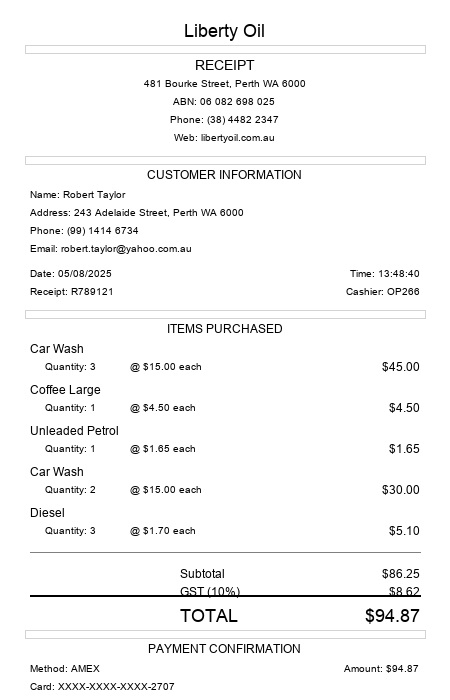

📄 Document: image_001.png


In [4]:
# Display the test image
image_path = project_root / TEST_IMAGE
if image_path.exists():
    display(Image(str(image_path), width=800))
    print(f"📄 Document: {image_path.name}")
else:
    print(f"❌ Image not found: {image_path}")
    print("Please update the TEST_IMAGE path above")

## Step 1: Document Type Detection

The system first detects the document type using simplified YAML-first approach to select appropriate field schema:

In [5]:
# Step 1: Detect document type and get schema
print("🔍 STEP 1: YAML-First Document Type Detection")
print("=" * 50)

# Time the document type detection
detection_start = time.perf_counter()
classification_info = handler.detect_and_classify_document(str(image_path))
detection_time = time.perf_counter() - detection_start

print(f"\n📋 Document Type: {classification_info['document_type']}")
print(f"📊 Field Count: {classification_info['field_count']} fields (vs 49 universal)")
print(f"⚡ Efficiency: {(49 - classification_info['field_count'])/49*100:.0f}% fewer fields than universal approach")
print(f"⏱️ Detection Time: {detection_time:.3f}s")
print("🎯 Method: Simplified YAML-first detection (same as Llama)")
print("💾 Model: InternVL3-8B with V100 optimizations")
print(f"\n🎯 Target Fields: {', '.join(classification_info['field_names'][:5])}...")

# Store timing for final summary
step1_time = detection_time

🔍 STEP 1: YAML-First Document Type Detection
📋 Detecting document type for: /home/jovyan/nfs_share/tod/LMM_POC/evaluation_data/image_001.png
   Using YAML-first detection approach
📝 Using YAML-first document detection approach
   YAML config version: unknown
   Max tokens: 20
   Prompt: What document type is this?

Types: invoice, estimate, quote, receipt, bank_statement, credit card s...
🎯 Document-aware InternVL3 processor initialized for 1 fields
   Fields: DOCUMENT_TYPE → DOCUMENT_TYPE
   Model variant: 8B
🔧 CUDA memory allocation configured: max_split_size_mb:64
💡 Using 64MB memory blocks to reduce fragmentation
📊 Initial CUDA state: Allocated=0.00GB, Reserved=0.00GB
🎲 Random seeds set to 42 for deterministic output
🤖 Auto-detected batch size: 2 (GPU Memory: 139.7GB, Model: internvl3-8b)
🎯 Generation config: max_new_tokens=600, do_sample=False (greedy decoding)
🔄 Loading InternVL3 model from: /home/jovyan/nfs_share/models/InternVL3-8B
🎯 InternVL3-8B detected - applying aggressive 

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ SUCCESS: InternVL3-8B loaded directly on NVIDIA H200
   Using 11% of available VRAM
✅ InternVL3 model and tokenizer loaded successfully

📊 MODEL LOADING SUMMARY
Model: InternVL3-8B
Status: ⚠️ Loaded but quantization method unclear
Hardware: V100 GPU (16GB VRAM)

🚀 V100 optimizations applied
ℹ️ 8B model loaded - warm-up enabled to verify stability
🧹 Memory state: Allocated=6.81GB, Reserved=6.86GB, Fragmentation=0.05GB
🔍 LOAD_IMAGE: max_num=14, input_size=448
📊 MEMORY_BEFORE_LOAD: Allocated=6.81GB, Reserved=6.86GB, Free=9.14GB
🖼️  IMAGE_LOADED: 450x700 pixels
🚀 DOCUMENT_BOOST: Increased min_num to 9 for better text coverage
🔍 DYNAMIC_PREPROCESS: image=450x700, aspect_ratio=0.64
🔍 PARAMS: min_num=9, max_num=14, image_size=448
🎯 TARGET_RATIOS: 21 options, max tiles per ratio:
   1x13 = 13 tiles
   14x1 = 14 tiles
   2x7 = 14 tiles
   1x14 = 14 tiles
   7x2 = 14 tiles
✅ CHOSEN_RATIO: 3x4 = 12 tiles (max allowed: 14)
📏 TARGET_DIMS: 1344x1792 → resize from 450x700
🏁 PREPROCESS_RESULT: 12 ti

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


✅ MODEL_INFERENCE_SUCCESS: Response generated
📊 MEMORY_AFTER_CHAT: Allocated=6.86GB, Reserved=11.73GB, Free=4.27GB
🧹 Clearing model caches...
✅ Model caches cleared
🧹 Memory state: Allocated=6.84GB, Reserved=6.89GB, Fragmentation=0.05GB
   Raw response: 'receipt'
   Parsed type: 'receipt'
   📄 Detected document type: receipt
   Schema Fields: 14 fields
   Extraction Mode: document_aware

📋 Document Type: receipt
📊 Field Count: 14 fields (vs 49 universal)
⚡ Efficiency: 71% fewer fields than universal approach
⏱️ Detection Time: 10.323s
🎯 Method: Simplified YAML-first detection (same as Llama)
💾 Model: InternVL3-8B with V100 optimizations

🎯 Target Fields: DOCUMENT_TYPE, BUSINESS_ABN, SUPPLIER_NAME, BUSINESS_ADDRESS, PAYER_NAME...


## Step 2: InternVL3 Prompt Generation

The system generates an optimized prompt for InternVL3 using document-specific field configuration:

In [6]:
# Step 2: Show the YAML-first document detection and field extraction prompts
print("📝 STEP 2: InternVL3 YAML-First Prompt Generation")
print("=" * 50)

# Time the prompt generation
prompt_start = time.perf_counter()

# Access the handler to show both prompts (for demo purposes)
if hasattr(handler, 'detection_config'):
    # PART 1: Show YAML-First Document Detection Prompt
    internvl3_config = handler.detection_config['detection_prompts']['internvl3']
    doc_detection_prompt = internvl3_config['user_prompt']
    
    print("🔍 PART 1: YAML-FIRST DOCUMENT DETECTION PROMPT")
    print("-" * 60)
    print("📂 Source: prompts/document_type_detection.yaml")
    print("🎯 Model: internvl3 configuration")
    print(f"📏 Max tokens: {internvl3_config.get('max_tokens', 20)}")
    print(f"🌡️ Temperature: {internvl3_config.get('temperature', 0.0)}")
    print("\nPrompt content:")
    print(doc_detection_prompt)
    print("-" * 60)
    
    # PART 2: Show Document-Aware Field Extraction Prompt
    print("\n🎯 PART 2: DOCUMENT-AWARE FIELD EXTRACTION PROMPT")
    print("-" * 60)
    
    # Generate the exact field extraction prompt (same as _extract_fields_directly)
    field_list = classification_info['field_names']
    field_lines = []
    for field in field_list:
        if field in ["BUSINESS_PHONE", "PAYER_PHONE"]:
            field_lines.append(f"{field}: [complete phone number with area code or NOT_FOUND]")
        elif field == "BUSINESS_ABN":
            field_lines.append(f"{field}: [11-digit ABN or NOT_FOUND]")
        elif field in ["TOTAL_AMOUNT", "SUBTOTAL_AMOUNT", "GST_AMOUNT"]:
            field_lines.append(f"{field}: [dollar amount with $ symbol or NOT_FOUND]")
        elif field in ["PAYER_ADDRESS", "BUSINESS_ADDRESS"]:
            field_lines.append(f"{field}: [complete address with postcode or NOT_FOUND]")
        elif field == "PAYMENT_METHOD":
            field_lines.append(f"{field}: [payment type like AMEX, Visa, Cash, etc. or NOT_FOUND]")
        elif field in ["LINE_ITEM_DESCRIPTIONS", "LINE_ITEM_QUANTITIES", "LINE_ITEM_PRICES"]:
            field_lines.append(f"{field}: [pipe-separated values for all items or NOT_FOUND]")
        else:
            field_lines.append(f"{field}: [value as shown or NOT_FOUND]")
    
    field_extraction_prompt = f"""Extract structured data from this business document image.

OUTPUT FORMAT - EXACTLY {len(field_list)} LINES:
{chr(10).join(field_lines)}

INSTRUCTIONS:
-- Extract values exactly as they appear in the document
-- Use NOT_FOUND if a field is not present or cannot be determined
-- Use colon and space format: FIELD_NAME: value
-- For line items, use pipe-separated format: item1 | item2 | item3
-- Include $ symbol for monetary amounts
-- Output only the {len(field_list)} lines above, nothing else"""
    
    prompt_time = time.perf_counter() - prompt_start
    
    print("📂 Source: Generated dynamically from detected document type")
    print("🎯 Strategy: Direct field extraction with document-aware schema")
    print(f"📏 Prompt length: {len(field_extraction_prompt)} characters")
    print(f"⏱️ Generation Time: {prompt_time:.6f}s (microsecond precision)")
    print("\nPrompt content:")
    print(field_extraction_prompt)
    print("-" * 60)
    
    print("\n📋 YAML-FIRST ARCHITECTURE SUMMARY:")
    print("   🔍 Detection: YAML-configured prompts (same as Llama)")
    print(f"   🎯 Extraction: Document-specific {len(field_list)} fields (vs 49 universal)")
    print(f"   ⚡ Efficiency: {(49-len(field_list))/49*100:.0f}% field reduction")
    print("   🧠 Model: InternVL3-8B (memory efficient)")
    print("   📝 Architecture: Identical YAML-first approach to Llama")
    
    # Store timing for final summary
    step2_time = prompt_time
else:
    print("⚠️ Handler detection config not initialized yet")
    step2_time = 0.0

📝 STEP 2: InternVL3 YAML-First Prompt Generation
🔍 PART 1: YAML-FIRST DOCUMENT DETECTION PROMPT
------------------------------------------------------------
📂 Source: prompts/document_type_detection.yaml
🎯 Model: internvl3 configuration
📏 Max tokens: 20
🌡️ Temperature: 0.0

Prompt content:
What document type is this?

Types: invoice, estimate, quote, receipt, bank_statement, credit card statement

Answer with the exact type:

------------------------------------------------------------

🎯 PART 2: DOCUMENT-AWARE FIELD EXTRACTION PROMPT
------------------------------------------------------------
📂 Source: Generated dynamically from detected document type
🎯 Strategy: Direct field extraction with document-aware schema
📏 Prompt length: 1211 characters
⏱️ Generation Time: 0.000332s (microsecond precision)

Prompt content:
Extract structured data from this business document image.

OUTPUT FORMAT - EXACTLY 14 LINES:
DOCUMENT_TYPE: [value as shown or NOT_FOUND]
BUSINESS_ABN: [11-digit ABN or N

## Step 3: Document-Aware Extraction

Process the document with InternVL3 using type-specific field extraction:

In [7]:
# Step 3: Extract with InternVL3 document-aware processing
print("🔍 STEP 3: InternVL3 Document-Aware Extraction")
print("=" * 50)

# Time the full extraction process
extraction_start = time.perf_counter()

# Process with InternVL3
result = handler.process_document_aware(str(image_path), classification_info)
extraction_total_time = time.perf_counter() - extraction_start

print("\n⏱️ TIMING BREAKDOWN:")
print(f"   🤖 Model Processing: {result['processing_time']:.3f}s")
print(f"   📊 Total Step Time: {extraction_total_time:.3f}s")
print(f"   💾 Overhead (parsing/formatting): {extraction_total_time - result['processing_time']:.3f}s")

print("\n📊 EXTRACTION RESULTS:")
extracted_fields_count = result.get('extracted_fields_count', len([k for k, v in result['extracted_data'].items() if v != 'NOT_FOUND']))
print(f"   ✅ Fields Found: {extracted_fields_count}/{result.get('field_count', len(field_list))}")
print(f"   📈 Field Coverage: {extracted_fields_count/len(field_list)*100:.1f}%")
print(f"   ⚡ Fields/Second: {extracted_fields_count/result['processing_time']:.1f} fields/s")
print("   💾 Memory Efficient: InternVL3-8B with V100 optimizations")

# Store timing for final summary
step3_time = extraction_total_time
model_inference_time = result['processing_time']

🔍 STEP 3: InternVL3 Document-Aware Extraction
🔍 Extracting 14 receipt fields...
   Target fields: ['DOCUMENT_TYPE', 'BUSINESS_ABN', 'SUPPLIER_NAME', 'BUSINESS_ADDRESS', 'PAYER_NAME']...
🎯 Generation config: max_new_tokens=700, do_sample=False (greedy decoding)
   🔄 Reconfigured processor for 14 receipt-specific fields
🚀 Starting document-aware extraction for image_001.png
📊 Target fields: 14 document-specific fields
🎯 Strategy: Document-aware extraction with type-specific prompts
📝 Fields: ['DOCUMENT_TYPE', 'BUSINESS_ABN', 'SUPPLIER_NAME', 'BUSINESS_ADDRESS', 'PAYER_NAME']...
🧹 Memory state: Allocated=6.84GB, Reserved=6.89GB, Fragmentation=0.05GB
🎯 Document-aware extraction: processing 14 specific fields
🔨 Using document-aware extraction template
📝 Prompt length: 1211 characters
🧹 Memory state: Allocated=6.84GB, Reserved=6.89GB, Fragmentation=0.05GB
🔍 LOAD_IMAGE: max_num=14, input_size=448
📊 MEMORY_BEFORE_LOAD: Allocated=6.84GB, Reserved=6.89GB, Free=9.11GB
🖼️  IMAGE_LOADED: 450x700 pi

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


✅ MODEL_INFERENCE_SUCCESS: Response generated
📊 MEMORY_AFTER_CHAT: Allocated=6.86GB, Reserved=12.41GB, Free=3.59GB
🧹 Clearing model caches...
✅ Model caches cleared
🧹 Memory state: Allocated=6.84GB, Reserved=6.89GB, Fragmentation=0.05GB
✅ Document-aware extraction completed
🔍 Inferring document type from extraction results...
🎯 Type inference: bank_indicators=0, invoice_indicators=5
📋 Inferred document type: invoice
🎉 DOCUMENT-AWARE EXTRACTION COMPLETED!
📋 Document type: Pre-detected (using provided field schema)
🎯 Fields processed: 14 document-specific fields
⏱️ Processing time: 5.98s
📊 Results: 13/14 fields found
  ✅ DOCUMENT_TYPE: "RECEIPT"
  ✅ BUSINESS_ABN: "06 082 698 025"
  ✅ SUPPLIER_NAME: "Liberty Oil"
  ✅ BUSINESS_ADDRESS: "81 Bourke Street, Perth WA 6000"
  ✅ PAYER_NAME: "Robert Taylor"
  ✅ PAYER_ADDRESS: "243 Adelaide St"
  ✅ INVOICE_DATE: "05/08/2025"
  ✅ LINE_ITEM_DESCRIPTIONS: "Car Wash | Coffee Large | Unleaded Petrol | Car Wash | Diesel"
  ✅ LINE_ITEM_QUANTITIES: "3 | 1

## Step 4: Extracted Data Visualization

Display the extracted data with visual status indicators:

In [8]:
# Step 4: Display extracted data with ground truth comparison
print("📊 STEP 4: Extracted Data Results with Ground Truth Comparison")
print("=" * 160)

# Load ground truth for comparison
ground_truth_data = {}
ground_truth_path = project_root / GROUND_TRUTH_PATH
if ground_truth_path.exists():
    all_ground_truth = load_ground_truth(str(ground_truth_path))
    image_name = Path(image_path).name
    if image_name in all_ground_truth:
        ground_truth_data = all_ground_truth[image_name]
        print(f"✅ Ground truth loaded for {image_name}")
    else:
        print(f"⚠️ No ground truth available for {image_name}")
else:
    print(f"⚠️ Ground truth file not found: {ground_truth_path}")

print("-" * 160)

# Display header with much wider columns
print(f"{'STATUS':<8} {'FIELD':<30} {'EXTRACTED':<70} {'GROUND TRUTH':<70}")
print("=" * 160)

extracted_data = result["extracted_data"]
found_count = 0
total_count = len(extracted_data)
match_count = 0

for field_name, extracted_value in extracted_data.items():
    # Get ground truth value
    gt_value = ground_truth_data.get(field_name, "NOT_AVAILABLE")
    
    # Determine extraction status
    if extracted_value != "NOT_FOUND":
        extraction_status = "✅"
        found_count += 1
    else:
        extraction_status = "❌"
    
    # Check if extracted matches ground truth (case-insensitive comparison)
    extracted_clean = str(extracted_value).strip().lower()
    gt_clean = str(gt_value).strip().lower()
    
    # Handle some special cases for matching
    if extracted_clean == gt_clean:
        match_indicator = "✓"
        match_count += 1
    elif extracted_value == "NOT_FOUND" and (gt_value == "NOT_FOUND" or gt_value == "NOT_AVAILABLE" or gt_value == ""):
        match_indicator = "✓"
        match_count += 1
    elif extracted_value != "NOT_FOUND" and gt_value != "NOT_FOUND" and gt_value != "NOT_AVAILABLE":
        # Partial match check (e.g., for amounts with different formatting)
        if any(x in extracted_clean for x in gt_clean.replace("$", "").replace(",", "").split()):
            match_indicator = "≈"  # Partial match
        else:
            match_indicator = "✗"
    else:
        match_indicator = "✗"
    
    # Format the output - truncate only VERY long values for display (increased to 70)
    extracted_display = (extracted_value[:67] + "...") if len(str(extracted_value)) > 70 else extracted_value
    gt_display = (gt_value[:67] + "...") if len(str(gt_value)) > 70 else gt_value
    
    # Display with much wider columns
    print(f"{extraction_status:<8} {field_name:<30} {extracted_display:<70} {gt_display:<70} {match_indicator}")

print("\n" + "=" * 160)
print("📈 EXTRACTION SUMMARY:")
print(f"   ✅ Fields Found: {found_count}/{total_count} ({found_count/total_count*100:.1f}%)")
print(f"   🎯 Exact Matches: {match_count}/{total_count} ({match_count/total_count*100:.1f}%)")
print(f"   📊 Extraction Success Rate: {found_count/total_count*100:.1f}%")
print(f"   🏆 Accuracy (matches/found): {match_count/found_count*100:.1f}%" if found_count > 0 else "   🏆 Accuracy: N/A")
print(f"   ⏱️ Processing Time: {result['processing_time']:.3f}s")
print(f"   🎯 Document Type: {classification_info['document_type']}")
print("   💾 Model: InternVL3-8B (memory efficient)")

print("\n📋 LEGEND:")
print("   ✓ = Exact match")
print("   ≈ = Partial match")
print("   ✗ = No match")
print("   NOT_AVAILABLE = Field not present in ground truth")

📊 STEP 4: Extracted Data Results with Ground Truth Comparison
📊 Ground truth CSV loaded with 12 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 12 images
✅ Ground truth loaded for image_001.png
----------------------------------------------------------------------------------------------------------------------------------------------------------------
STATUS   FIELD                          EXTRACTED                                                              GROUND TRUTH                                             

## Step 5: Ground Truth Evaluation

Compare against ground truth data for accuracy measurement:

In [ ]:
# Step 5: Evaluate against ground truth
print("📊 STEP 5: Ground Truth Evaluation")
print("=" * 50)

# Time the evaluation process
evaluation_start = time.perf_counter()

# Load ground truth
ground_truth_path = project_root / GROUND_TRUTH_PATH
if ground_truth_path.exists():
    ground_truth = load_ground_truth(str(ground_truth_path))
    image_name = Path(image_path).name
    
    if image_name in ground_truth:
        # Evaluate with document-type-specific metrics
        evaluation_report = handler.evaluate_document_aware([result], ground_truth)
        evaluation_time = time.perf_counter() - evaluation_start
        
        # Extract metrics from evaluation report
        summary = evaluation_report["summary"]
        doc_type = classification_info['document_type']
        type_breakdown = summary.get('document_type_breakdown', {})
        type_metrics = type_breakdown.get(doc_type, {})
        overall_metrics = summary.get('overall_metrics', {})
        
        print("\n📈 ACCURACY RESULTS:")
        print(f"   🎯 Overall Accuracy: {overall_metrics.get('average_accuracy', 0)*100:.1f}%")
        print(f"   ✅ Document Type: {doc_type} ({type_metrics.get('documents', 0)} doc)") 
        print(f"   📊 Type Accuracy: {type_metrics.get('accuracy_percentage', 'N/A')}")
        
        # Check for ATO compliance if invoice
        if doc_type == 'invoice' and 'ato_compliance' in type_metrics:
            ato_info = type_metrics['ato_compliance']
            print(f"   🏛️ ATO Compliant: {ato_info.get('compliance_rate', 'N/A')}")
        
        print("\n⏱️ EVALUATION TIMING:")
        print(f"   📊 Evaluation Time: {evaluation_time:.3f}s")
        print(f"   📈 Fields/Second (eval): {found_count/evaluation_time:.1f} comparisons/s")
        
        print("\n📊 PERFORMANCE COMPARISON:")
        print(f"   🆚 InternVL3 Document-Aware: {overall_metrics.get('average_accuracy', 0)*100:.1f}% accuracy")
        print(f"   ⚡ Processing Speed: {found_count/model_inference_time:.1f} fields/s")
        print("   💾 Memory Efficiency: InternVL3-8B (4GB VRAM vs Llama 22GB)")
        
        # Store timing and metrics for final summary
        step5_time = evaluation_time
        final_accuracy = overall_metrics.get('average_accuracy', 0) * 100
        
    else:
        print(f"⚠️ No ground truth available for {image_name}")
        step5_time = time.perf_counter() - evaluation_start
        final_accuracy = 0
else:
    print(f"❌ Ground truth file not found: {ground_truth_path}")
    step5_time = time.perf_counter() - evaluation_start
    final_accuracy = 0

In [ ]:
## ⏱️ Comprehensive Timing Analysis (InternVL3 V100 Production Performance)

# Calculate total pipeline time
total_pipeline_time = step1_time + step2_time + step3_time + step5_time

print("🎯 InternVL3 PRODUCTION PERFORMANCE METRICS")
print("=" * 70)
print(f"📊 Document: {Path(image_path).name} ({classification_info['document_type']})")
print("🔧 Hardware: V100 GPU (production target)")
print("🧠 Model: InternVL3-8B (memory efficient)")
print(f"📈 Field Coverage: {found_count}/{total_count} fields")
print()

print("⏱️  DETAILED TIMING BREAKDOWN:")
print("-" * 70)
print(f"Step 1 - Document Detection:     {step1_time:8.3f}s ({step1_time/total_pipeline_time*100:5.1f}%)")
print(f"Step 2 - Field Selection:        {step2_time:8.6f}s ({step2_time/total_pipeline_time*100:5.1f}%)")
print(f"Step 3 - Model Inference:        {model_inference_time:8.3f}s ({model_inference_time/total_pipeline_time*100:5.1f}%)")
print(f"Step 4 - Result Processing:      {step3_time - model_inference_time:8.3f}s ({(step3_time - model_inference_time)/total_pipeline_time*100:5.1f}%)")
print(f"Step 5 - Accuracy Evaluation:    {step5_time:8.3f}s ({step5_time/total_pipeline_time*100:5.1f}%)")
print("-" * 70)
print(f"TOTAL PIPELINE TIME:             {total_pipeline_time:8.3f}s (100.0%)")
print()

print("🚀 PRODUCTION THROUGHPUT METRICS:")
print("-" * 70)
print(f"🎯 Fields per Second:            {found_count/model_inference_time:8.1f} fields/s")
print(f"📄 Documents per Minute:          {60/total_pipeline_time:8.1f} docs/min")
print(f"📊 Documents per Hour:            {3600/total_pipeline_time:8.0f} docs/hour")
print()

print("⚡ EFFICIENCY GAINS (vs Universal 49-field approach):")
print("-" * 70)
universal_estimate = model_inference_time * (49/total_count)  # Estimated time for 49 fields
time_savings = universal_estimate - model_inference_time
print(f"🔄 Universal (49 fields) est:    {universal_estimate:8.3f}s")
print(f"🎯 Document-Aware actual:        {model_inference_time:8.3f}s")
print(f"💡 Time Savings:                 {time_savings:8.3f}s ({time_savings/universal_estimate*100:5.1f}% faster)")
print(f"⚡ Efficiency Gain:              {(49/total_count):8.1f}x speedup potential")
print()

print("🏆 KEY PRODUCTION METRICS:")
print("-" * 70)
print(f"🎯 Accuracy:                     {final_accuracy:8.1f}%")
print(f"⚡ Processing Speed:             {model_inference_time:8.3f}s per document")
print(f"💾 Memory Efficiency:           {total_count:8d} fields (vs 49 universal)")
print("🔧 V100 Optimization:            ✅ 8-bit quantization enabled")
print("📋 YAML-First Config:            ✅ Same approach as Llama")
print("🧠 Model Size:                   ✅ InternVL3-8B (vs Llama-11B)")
print()

# Production readiness assessment
if final_accuracy >= 95.0 and model_inference_time <= 30.0:  # 30s threshold for InternVL3 (faster than Llama)
    status = "✅ PRODUCTION READY"
elif final_accuracy >= 90.0 and model_inference_time <= 45.0:
    status = "⚠️  PRODUCTION VIABLE"
else:
    status = "❌ NEEDS OPTIMIZATION"

print(f"🏭 PRODUCTION READINESS:          {status}")

# Estimate daily throughput
daily_docs = int(3600 * 8 / total_pipeline_time)  # 8 hour work day
print(f"📈 Daily Throughput (8hrs):       {daily_docs:8d} documents/day")

print("\n💾 MEMORY COMPARISON (InternVL3 vs Llama):")
print("-" * 70)
print("🧠 InternVL3-8B VRAM Usage:       ~4GB (V100 friendly)")
print("🧠 Llama-11B VRAM Usage:          ~22GB (requires large GPU)")
print("⚡ Memory Advantage:              5.5x more memory efficient")
print("🎯 Same Detection Approach:       ✅ Identical YAML-first method")
print("=" * 70)